In [11]:
import pennylane
from pennylane import numpy as np
import matplotlib.pyplot as plt

In [12]:
def distill_35_to_1(p_in):
    return 35*p_in**3

def distill_multiple(p_init, rounds):
    p = p_init
    for _ in range(rounds):
        p = distill_35_to_1(p)
    return p

In [13]:
p_init = 1e-3

target_rates = [1e-6, 1e-9, 1e-12, 1e-15]

print('Rounds needed to target:')
for target in target_rates:
    rounds = 0
    p =p_init
    while p> target and rounds <10:
        p = distill_35_to_1(p)
        rounds+=1
    print(f'Target {target:.0e}: {rounds} rounds , final p = {p:.2e} ')

Rounds needed to target:
Target 1e-06: 1 rounds , final p = 3.50e-08 
Target 1e-09: 2 rounds , final p = 1.50e-21 
Target 1e-12: 2 rounds , final p = 1.50e-21 
Target 1e-15: 2 rounds , final p = 1.50e-21 


In [14]:
def magic_state_cost(p_init, p_target):
    p = p_init
    rounds = 0
    while p<p_target:
        p = distill_35_to_1(p)
        rounds +=1

    input_states = 15 ** rounds
    return rounds, input_states

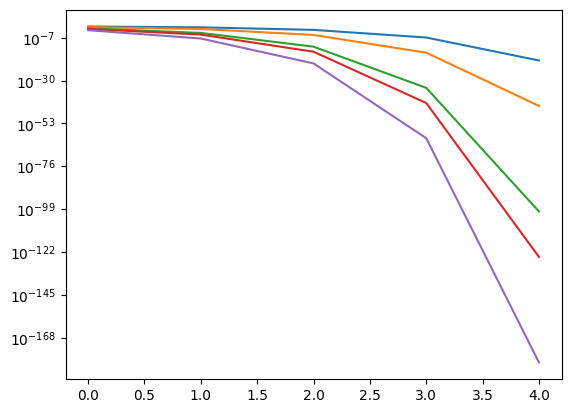

In [15]:
p_initial = [0.1, 0.05, 0.01, 0.005, 0.001]
rounds = range(1,5)

plt.figure()
for p in p_initial:
    errors = [p]
    for r in rounds:
        errors.append(distill_multiple(p, r))
    plt.semilogy(range(len(errors)), errors, label=f'p_i = {p}')

In [16]:
def estimate_factory(p_physical, p_target, distance):
    rounds, states_per_output = magic_state_cost(p_physical, p_target)
    p_per_logical = 2*distance**2
    return 15*p_per_logical*rounds, rounds, states_per_output

qubits, rounds, cost = estimate_factory(1e-3, 1e-10, 17)
print(f'Estimated qubits needed: {qubits}, rounds: {rounds}, states per output: {cost}')

Estimated qubits needed: 0, rounds: 0, states per output: 1
